In [17]:
import sys
!conda install --yes --prefix {sys.prefix} numpy matplotlib

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.



numpy does the math and matplotlib draws the graphs

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Utility: ridge regression

In [19]:
def ridge_regression(X_train, y_train, X_test, beta=1e-6):
    I = np.eye(X_train.shape[1])
    W = np.linalg.solve(X_train.T @ X_train + beta * I, X_train.T @ y_train)
    y_pred = X_test @ W
    return y_pred, W

# 2. Generate NARMA10 target

In [20]:
def generate_narma10(u):
    T = len(u)
    y = np.zeros(T)
    for t in range(10, T - 1):
        y[t + 1] = (
            0.3 * y[t]
            + 0.05 * y[t] * np.sum(y[t - 9:t + 1])
            + 1.5 * u[t - 9] * u[t]
            + 0.1
        )
    return y

# 3. Simulate interference reservoir

In [26]:
# Building the reservoir and running the input signal through it 

def simulate_interference_reservoir(
    T=6000,
    N=500,
    M=20,
    dt=1.0,
    seed=1
):
    rng = np.random.default_rng(seed)

    # input signal
    u = rng.uniform(0.0, 0.5, size=T)

    # loop parameters
    A = rng.uniform(0.5, 1.5, size=N)
    alpha = rng.normal(0.0, 1.0, size=N)
    tau = rng.integers(1, 16, size=N).astype(float)   # 1 to 15
    lam = np.exp(-dt / tau)

    # initial phases
    phi = rng.uniform(0, 2 * np.pi, size=N)

    # electrode mixing matrix
    Wmix = rng.normal(0.0, 1.0 / np.sqrt(N), size=(M, N))

    # state arrays
    s = np.zeros(N)
    R = np.zeros((T, M))

    for t in range(T):
        # loop-specific fading memory
        s_prev = s.copy()
        s = lam * s + (1.0 - lam) * u[t]

        # phase driven by change in input (delta-s fix)
        delta_s = s - s_prev
        phi = phi + alpha * delta_s * dt
        # loop conductance contributions
        g = A * np.cos(phi)

        # probe electrode signals
        R[t, :] = Wmix @ g

    return u, R

# 4. Memory capacity calculation

In [27]:
def memory_capacity(u, X, delays, washout=500, train_len=2500, test_len=2000):
    mc = []

    for d in delays:
        # training
        X_train = X[washout + d : washout + train_len]
        y_train = u[washout : washout + train_len - d]

        # testing
        X_test = X[washout + train_len : washout + train_len + test_len]
        y_test = u[washout + train_len - d : washout + train_len + test_len - d]

        y_pred, _ = ridge_regression(X_train, y_train, X_test)

        corr = np.corrcoef(y_pred.ravel(), y_test.ravel())[0, 1]
        score = 0.0 if np.isnan(corr) else corr**2
        mc.append(score)

    return np.array(mc)

# 5. NARMA10 prediction

In [28]:
def narma10_prediction(u, X, washout=500, train_len=2500, test_len=2000):
    y = generate_narma10(u)

    X_train = X[washout : washout + train_len]
    y_train = y[washout : washout + train_len]

    X_test = X[washout + train_len : washout + train_len + test_len]
    y_test = y[washout + train_len : washout + train_len + test_len]

    y_pred_train, Wout = ridge_regression(X_train, y_train, X_train)
    y_pred_test = X_test @ Wout

    nmse_train = np.mean((y_pred_train - y_train)**2) / np.var(y_train)
    nmse_test = np.mean((y_pred_test - y_test)**2) / np.var(y_test)

    return y_train, y_pred_train, y_test, y_pred_test, nmse_train, nmse_test

# 6. Main script

Train NMSE = 0.3430
Test  NMSE = 0.2982


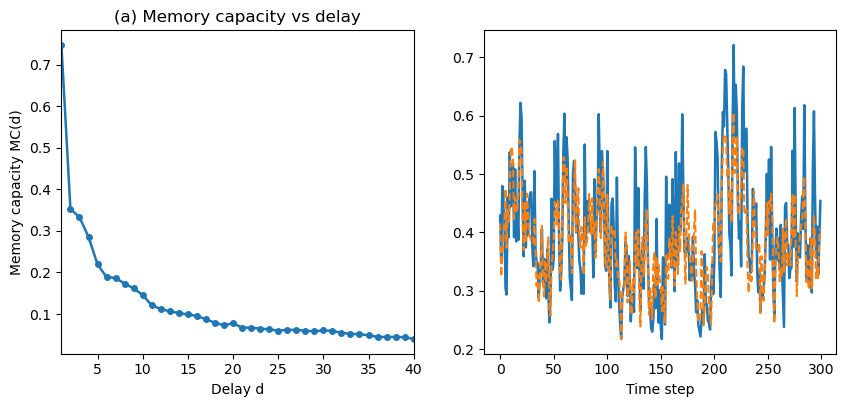

In [29]:
if __name__ == "__main__":
    # simulate reservoir
    u, R = simulate_interference_reservoir(
        T=6000,
        N=500,
        M=20,
        dt=1.0,
        seed=7
    )

    # reservoir features
    # using probe signals directly is the cleanest choice
    X = np.hstack([R, np.ones((R.shape[0], 1))])

    # memory capacity
    delays = np.arange(1, 41)
    mc = memory_capacity(u, X, delays)

    # NARMA10
    y_train, y_pred_train, y_test, y_pred_test, nmse_train, nmse_test = narma10_prediction(u, X)

    print(f"Train NMSE = {nmse_train:.4f}")
    print(f"Test  NMSE = {nmse_test:.4f}")

    # -------------------------
    # Figure 3
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    # Fig. 3(a): memory capacity
    axes[0].plot(delays, mc, 'o-', lw=1.8, ms=4)
    axes[0].set_xlabel("Delay d")
    axes[0].set_ylabel("Memory capacity MC(d)")
    axes[0].set_title("(a) Memory capacity vs delay")
    axes[0].set_xlim(delays.min(), delays.max())

    # Fig. 3(b): NARMA10 test prediction
    n_show = 300
    t_axis = np.arange(n_show)
    axes[1].plot(t_axis, y_test[:n_show], lw=1.8, label="Target")
    axes[1].plot(t_axis, y_pred_test[:n_show], lw=1.5, ls="--", label="Predicted")
    axes[1].set_xlabel("Time step")
